# Glint Analysis

Sun glint (specular reflection of sunlight off water surfaces) is a critical factor
in planning airborne remote sensing over coastal and aquatic environments. This notebook
demonstrates how to use HyPlan's glint module to:

1. Compute glint angles for arbitrary sun/view geometries
2. Map glint angles across a flight line's swath
3. Evaluate how flight heading and time of day affect glint contamination

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta
import geopandas as gpd

from hyplan.glint import glint_angle, compute_glint_vectorized
from hyplan.instruments import AVIRIS3
from hyplan.flight_line import FlightLine
from hyplan.sun import solar_position_increments, plot_solar_positions
from hyplan.units import ureg


## 1. Glint Angle Fundamentals

The glint angle is the angular distance between the sensor viewing direction and the
specular reflection direction. A glint angle of 0 means the sensor is looking directly
at the sun's specular reflection point.

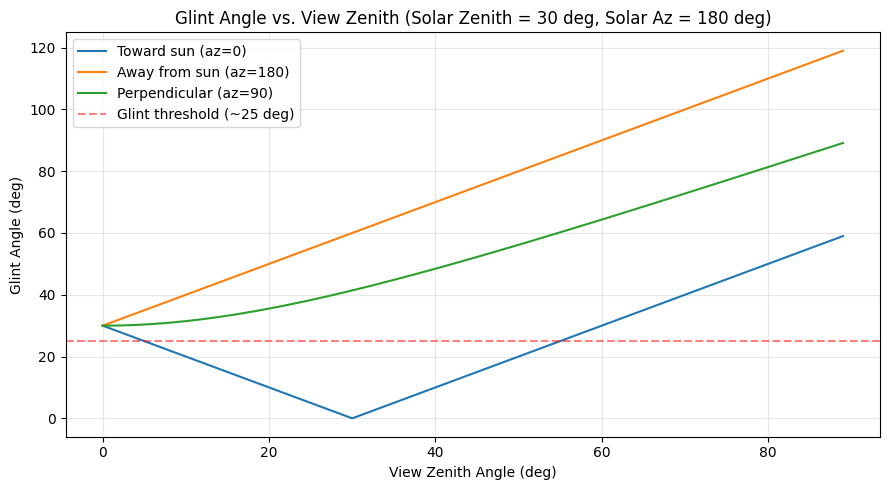

In [2]:
# Vary view zenith angle while keeping sun fixed
solar_az = np.full(90, 180.0)   # Sun from the south
solar_zen = np.full(90, 30.0)   # 30 deg solar zenith
view_zen = np.linspace(0, 89, 90)

# Case 1: Looking toward the sun (view azimuth = 0, opposite of solar azimuth 180)
ga_toward = glint_angle(solar_az, solar_zen, np.full(90, 0.0), view_zen)

# Case 2: Looking away from the sun (view azimuth = 180, same as solar azimuth)
ga_away = glint_angle(solar_az, solar_zen, np.full(90, 180.0), view_zen)

# Case 3: Looking perpendicular to the sun (view azimuth = 90)
ga_perp = glint_angle(solar_az, solar_zen, np.full(90, 90.0), view_zen)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(view_zen, ga_toward, label="Toward sun (az=0)")
ax.plot(view_zen, ga_away, label="Away from sun (az=180)")
ax.plot(view_zen, ga_perp, label="Perpendicular (az=90)")
ax.axhline(y=25, color="red", linestyle="--", alpha=0.5, label="Glint threshold (~25 deg)")
ax.set_xlabel("View Zenith Angle (deg)")
ax.set_ylabel("Glint Angle (deg)")
ax.set_title(f"Glint Angle vs. View Zenith (Solar Zenith = 30 deg, Solar Az = 180 deg)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Solar Position at the Study Site

Before analyzing glint across a flight line, let's examine the solar geometry at our
target location throughout the day.

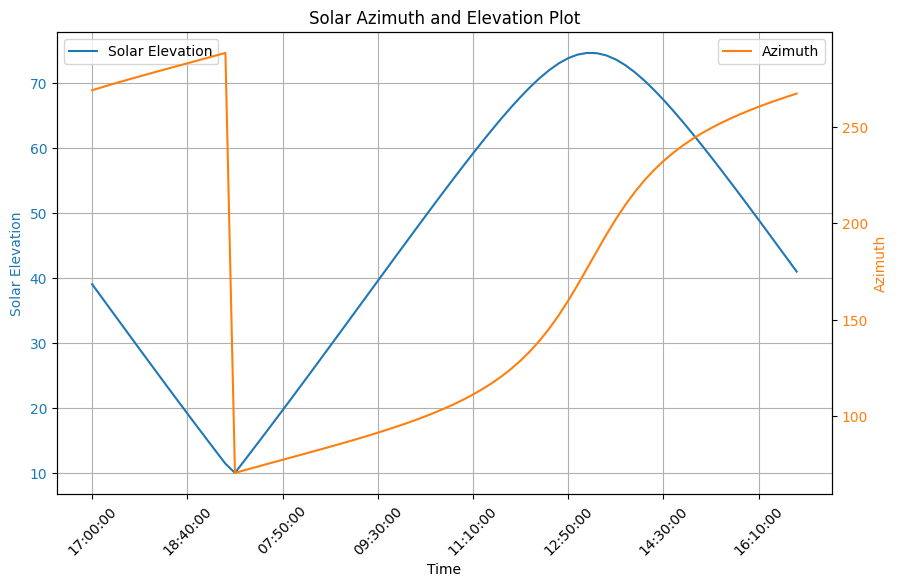

In [3]:
# Monterey Bay, California
lat, lon = 36.8, -121.9
date = datetime(2025, 7, 15)

# Get solar positions for the day (Pacific time = UTC-7)
df_solar = solar_position_increments(lat, lon, date, min_elevation=10, timezone_offset=-7)
plot_solar_positions(df_solar)

## 3. Glint Map Across a Flight Line

Use `compute_glint_vectorized` to compute glint angles at every pixel across the
sensor's swath for a flight line over Monterey Bay.

In [4]:
fl = FlightLine.start_length_azimuth(
    lat1=36.8, lon1=-121.9,
    length=ureg.Quantity(20, "km"),
    az=315.0,  # Northwest heading
    altitude_msl=ureg.Quantity(6000, "meter"),
    site_name="Monterey Bay",
)

sensor = AVIRIS3()
obs_time = datetime(2025, 7, 15, 19, 0, tzinfo=timezone.utc)  # Noon Pacific

gdf = compute_glint_vectorized(fl, sensor, obs_time)
print(f"Computed {len(gdf)} glint points")
print(f"Glint angle range: {gdf['glint_angle'].min():.1f} - {gdf['glint_angle'].max():.1f} deg")
gdf.head()

Computed 8241 glint points
Glint angle range: 22.1 - 31.4 deg


,target_latitude,target_longitude,glint_angle,tilt_angle,viewing_azimuth,along_track_distance,geometry
0,36.786234,-121.917113,27.778992,19.8,225.0,0.0,POINT (-121.91711 36.78623)
1,36.786983,-121.916182,27.198341,18.8,225.0,0.0,POINT (-121.91618 36.78698)
2,36.787724,-121.915262,26.640646,17.8,225.0,0.0,POINT (-121.91526 36.78772)
3,36.788456,-121.914352,26.107385,16.8,225.0,0.0,POINT (-121.91435 36.78846)
4,36.789181,-121.913451,25.600094,15.8,225.0,0.0,POINT (-121.91345 36.78918)


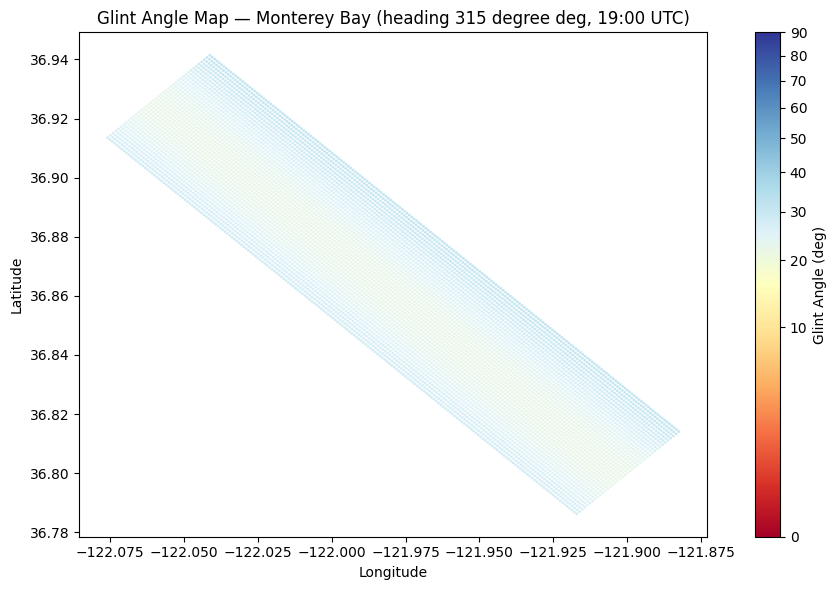

In [5]:
from matplotlib.colors import PowerNorm

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=gdf["glint_angle"], cmap="RdYlBu", s=1,
    norm=PowerNorm(gamma=0.4, vmin=0, vmax=90)
)
plt.colorbar(scatter, ax=ax, label="Glint Angle (deg)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Glint Angle Map — {fl.site_name} (heading {fl.az12:.0f} deg, {obs_time.strftime('%H:%M UTC')})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Effect of Flight Heading on Glint

Compare glint contamination for different flight headings at the same time of day.
This helps determine optimal heading to minimize or maximize glint.

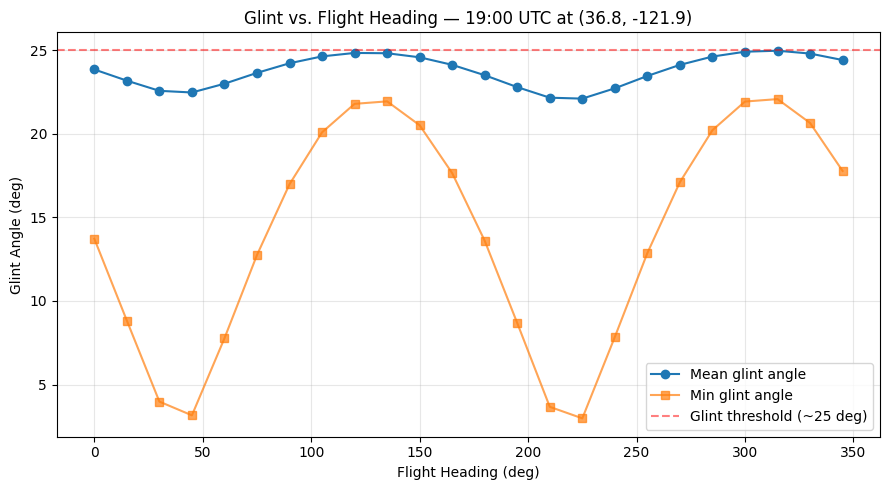

In [6]:
headings = np.arange(0, 360, 15)
mean_glints = []
min_glints = []

for hdg in headings:
    fl_test = FlightLine.start_length_azimuth(
        lat1=36.8, lon1=-121.9,
        length=ureg.Quantity(15, "km"),
        az=float(hdg),
        altitude_msl=ureg.Quantity(6000, "meter"),
        site_name=f"Heading {hdg}",
    )
    gdf_test = compute_glint_vectorized(fl_test, sensor, obs_time)
    mean_glints.append(gdf_test["glint_angle"].mean())
    min_glints.append(gdf_test["glint_angle"].min())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(headings, mean_glints, "o-", label="Mean glint angle")
ax.plot(headings, min_glints, "s-", label="Min glint angle", alpha=0.7)
ax.axhline(y=25, color="red", linestyle="--", alpha=0.5, label="Glint threshold (~25 deg)")
ax.set_xlabel("Flight Heading (deg)")
ax.set_ylabel("Glint Angle (deg)")
ax.set_title(f"Glint vs. Flight Heading — {obs_time.strftime('%H:%M UTC')} at ({lat}, {lon})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Flight Box Azimuth and Glint Contamination

A pushbroom sensor's cross-track field of view is perpendicular to the flight heading.
Glint peaks when those cross-track view directions align with the solar principal plane
(the vertical plane containing the sun and its specular reflection).

- **Poorly chosen azimuth** — flight lines run *perpendicular* to the principal plane.
  Cross-track views point directly toward or away from the sun's reflection. One side of
  every flight line lands near the specular point (glint angle ≈ 0); the other side
  points away from it. Mean glint angle ends up close to the solar zenith because the
  two sides cancel — the **spread** and the **minimum** are what matter, not the mean.
- **Well-chosen azimuth** — flight lines run *along* the principal plane (parallel to the
  solar azimuth). Cross-track views are perpendicular to the principal plane, so glint
  angle stays tightly clustered near the solar zenith across the entire swath.

We use a mid-morning observation time so the solar zenith is large enough that the
well-chosen geometry actually clears the 25° glint threshold; at solar noon in summer
the sun sits too close to nadir for any heading to fully escape contamination.

The two boxes below use the same location, altitude, and time; only the box azimuth differs.

In [7]:
import pandas as pd
from sunposition import sunpos
from hyplan.flight_box import box_around_center_line
from hyplan.geometry import wrap_to_180
from hyplan.glint import fraction_exceeding_glint_threshold

# Use a mid-morning time so SZA is large enough to demonstrate the effect.
# At solar noon in July at 36.8N, SZA is only ~22 deg — barely above AVIRIS-3's
# 19.8 deg half-angle — and no heading can clear the glint threshold.
box_obs_time = datetime(2025, 7, 15, 17, 30, tzinfo=timezone.utc)  # 10:30 PDT

# Solar geometry at the observation time
solar_az_val, solar_zen_val, *_ = sunpos(
    dt=box_obs_time, latitude=lat, longitude=lon, elevation=0.0, radians=False
)
solar_az_val = float(solar_az_val)
solar_zen_val = float(solar_zen_val)
print(f"Solar azimuth: {solar_az_val:.1f}°,  Solar zenith: {solar_zen_val:.1f}°")

altitude = ureg.Quantity(6000, "meter")
box_length = ureg.Quantity(20, "km")
box_width  = ureg.Quantity(15, "km")

# Poorly chosen: flight lines perpendicular to the principal plane
# Cross-track views point toward/away from the sun's reflection
bad_az  = wrap_to_180(solar_az_val + 90.0)

# Well-chosen: flight lines along the principal plane
# Cross-track views are perpendicular to the sun's reflection geometry
good_az = wrap_to_180(solar_az_val)

lines_bad  = box_around_center_line(sensor, altitude, lat, lon, bad_az,  box_length, box_width)
lines_good = box_around_center_line(sensor, altitude, lat, lon, good_az, box_length, box_width)

def compute_box_glint(flight_lines, obs_time):
    return pd.concat(
        [compute_glint_vectorized(fl, sensor, obs_time) for fl in flight_lines],
        ignore_index=True,
    )

gdf_bad  = compute_box_glint(lines_bad,  box_obs_time)
gdf_good = compute_box_glint(lines_good, box_obs_time)

print(f"\n{'case':<16}{'min':>8}{'max':>8}{'std':>8}{'<25°':>10}")
for label, az, gdf in [("Poorly chosen", bad_az, gdf_bad), ("Well chosen", good_az, gdf_good)]:
    ga = gdf["glint_angle"]
    frac_below_25 = fraction_exceeding_glint_threshold(gdf, 25) * 100
    print(f"{label:<16}{ga.min():>7.1f}°{ga.max():>7.1f}°{ga.std():>7.1f}°{frac_below_25:>9.0f}%")

Solar azimuth: 102.0°,  Solar zenith: 38.5°

case                 min     max     std      <25°
Poorly chosen      18.3°   58.8°   11.8°       17%
Well chosen        38.5°   42.9°    1.3°        0%


/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_66005/691506782.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


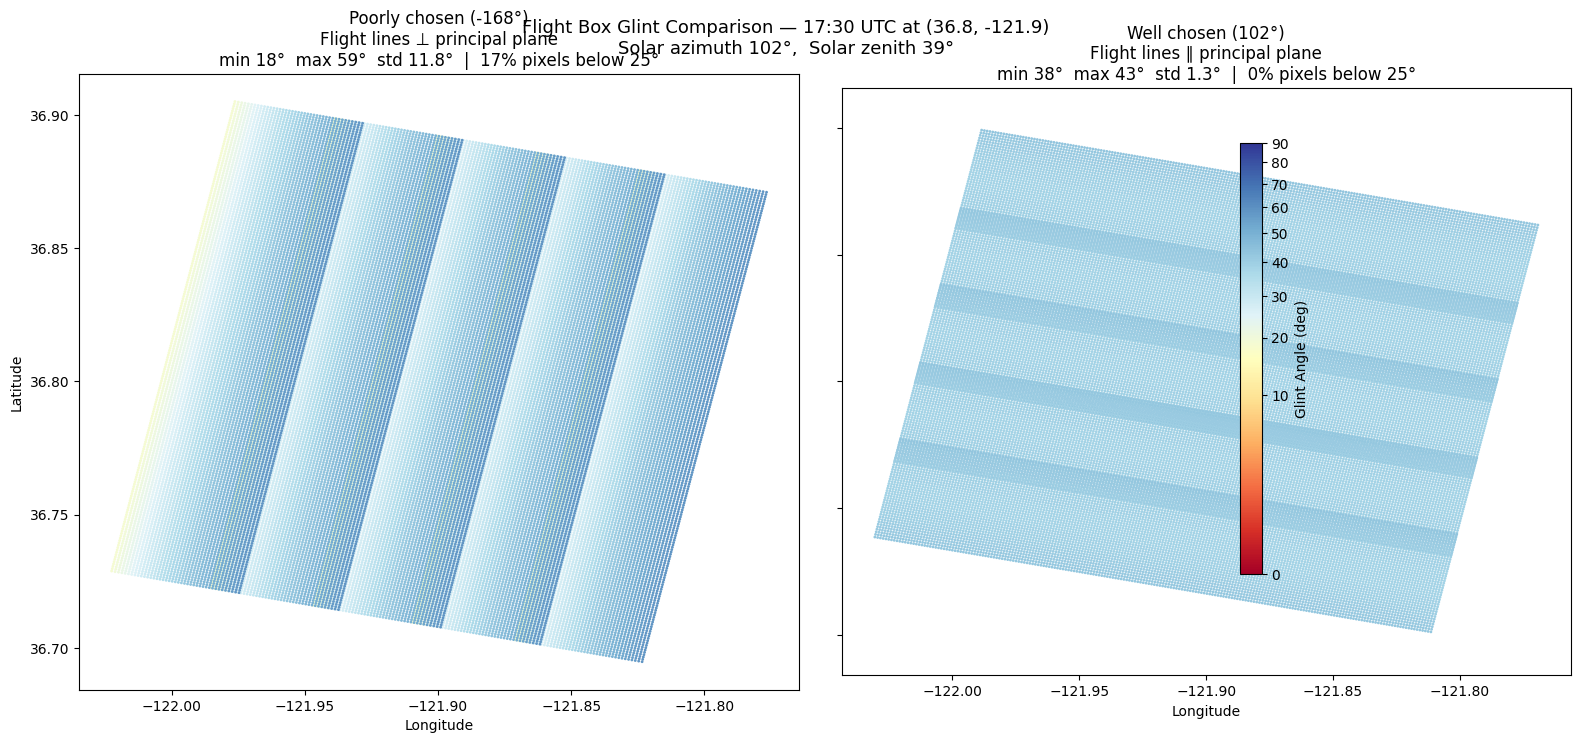

In [8]:
from matplotlib.colors import PowerNorm
from hyplan.glint import fraction_exceeding_glint_threshold

norm = PowerNorm(gamma=0.4, vmin=0, vmax=90)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

cases = [
    (axes[0], gdf_bad,  bad_az,  f"Poorly chosen ({bad_az:.0f}°)\nFlight lines ⊥ principal plane"),
    (axes[1], gdf_good, good_az, f"Well chosen ({good_az:.0f}°)\nFlight lines ∥ principal plane"),
]

for ax, gdf, az, title in cases:
    sc = ax.scatter(
        gdf.geometry.x, gdf.geometry.y,
        c=gdf["glint_angle"], cmap="RdYlBu", s=1, norm=norm,
    )
    ga = gdf["glint_angle"]
    frac = fraction_exceeding_glint_threshold(gdf, 25) * 100
    ax.set_title(
        f"{title}\nmin {ga.min():.0f}°  max {ga.max():.0f}°  std {ga.std():.1f}°  |  {frac:.0f}% pixels below 25°"
    )
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")

axes[0].set_ylabel("Latitude")
plt.colorbar(sc, ax=axes.tolist(), label="Glint Angle (deg)", shrink=0.8)
fig.suptitle(
    f"Flight Box Glint Comparison — {box_obs_time.strftime('%H:%M UTC')} at ({lat}, {lon})\n"
    f"Solar azimuth {solar_az_val:.0f}°,  Solar zenith {solar_zen_val:.0f}°",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 6. Glint Variation Through the Day

For a fixed flight heading, see how glint changes with time of day.

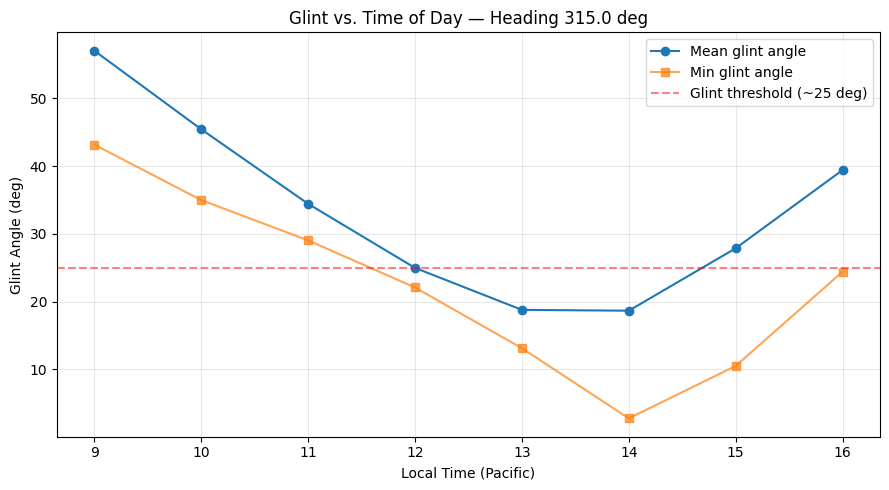

In [9]:
hours_utc = np.arange(16, 24)  # 9am - 5pm Pacific
fixed_heading = 315.0

fl_fixed = FlightLine.start_length_azimuth(
    lat1=36.8, lon1=-121.9,
    length=ureg.Quantity(15, "km"),
    az=fixed_heading,
    altitude_msl=ureg.Quantity(6000, "meter"),
    site_name="Monterey Bay",
)

time_mean_glint = []
time_min_glint = []

for h in hours_utc:
    t = datetime(2025, 7, 15, int(h), 0, tzinfo=timezone.utc)
    gdf_t = compute_glint_vectorized(fl_fixed, sensor, t)
    time_mean_glint.append(gdf_t["glint_angle"].mean())
    time_min_glint.append(gdf_t["glint_angle"].min())

fig, ax = plt.subplots(figsize=(9, 5))
local_hours = hours_utc - 7
ax.plot(local_hours, time_mean_glint, "o-", label="Mean glint angle")
ax.plot(local_hours, time_min_glint, "s-", label="Min glint angle", alpha=0.7)
ax.axhline(y=25, color="red", linestyle="--", alpha=0.5, label="Glint threshold (~25 deg)")
ax.set_xlabel("Local Time (Pacific)")
ax.set_ylabel("Glint Angle (deg)")
ax.set_title(f"Glint vs. Time of Day — Heading {fixed_heading} deg")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()